In [39]:
import obspy
import matplotlib.pyplot as plt
data = obspy.read('./RAW/*.SAC')

In [ ]:
stations = set(tr.stats.station for tr in data)
for station in stations:
    print(f"Station: {station}")


Station: C28O
Station: A29C
Station: A28C
Station: A08C
Station: A07C
Station: AC04
Station: C03O
Station: A30C
Station: PB19
Station: A06C
Station: A10C
Station: AC05
Station: C14O
Station: AC01
Station: GO03
Station: C16O
Station: A19C
Station: C15O
Station: A02C
Station: A24F
Station: A18C
Station: A32C
Station: A09C


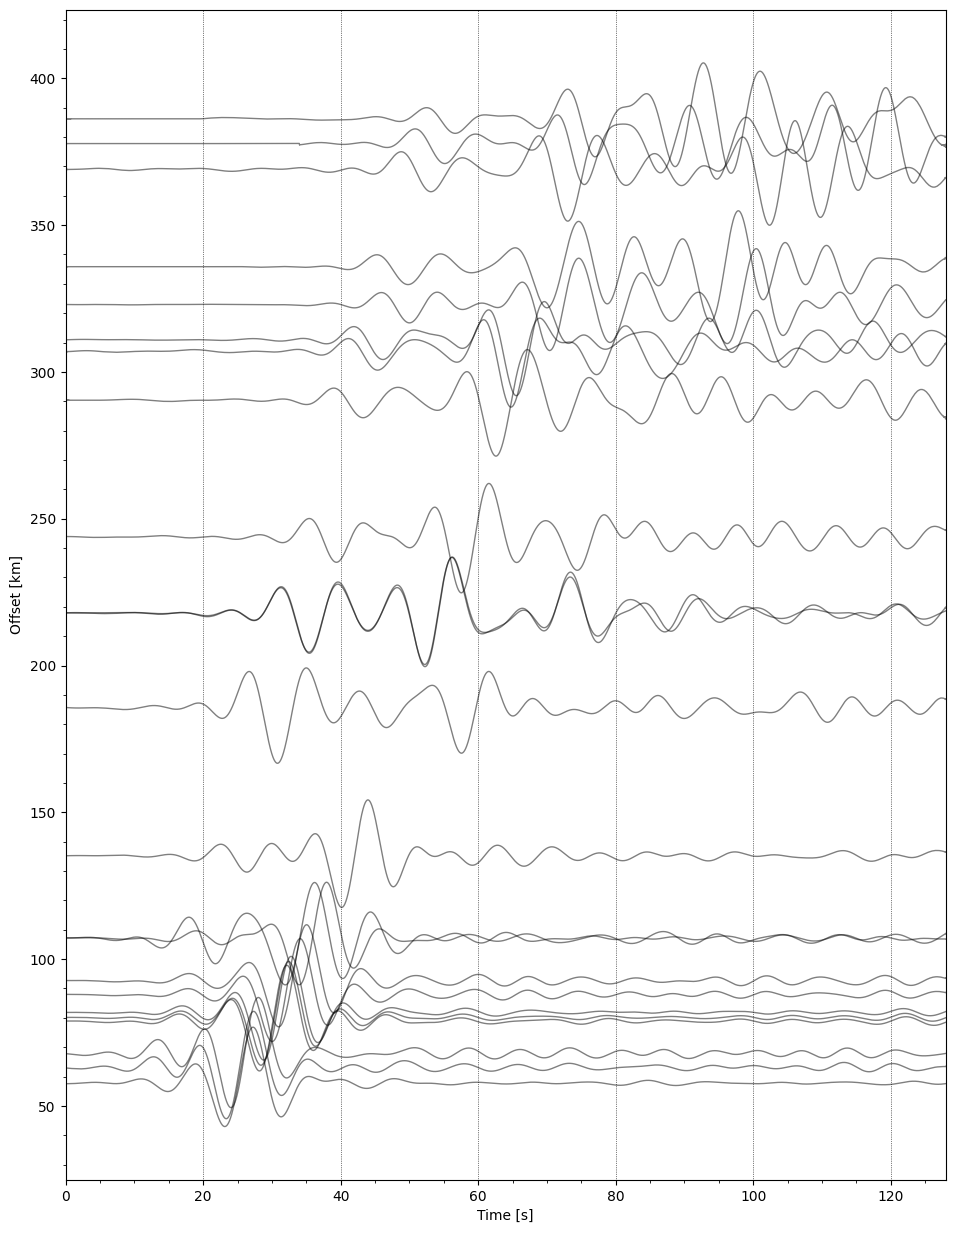

In [49]:
evlat, evlon = -26.639, -70.404 #km
evtime = obspy.UTCDateTime("2025-06-06T17:15:06.000")
data2=data.copy()
for tr in data2:
    tr.filter('bandpass', freqmin=0.04, freqmax=0.15, corners=4, zerophase=True)
    tr.trim(starttime=evtime, endtime=evtime+128,fill_value=0,pad=True)
    stlat, stlon = tr.stats.sac.stla, tr.stats.sac.stlo
    tr.stats.distance= obspy.geodetics.gps2dist_azimuth(evlat, evlon, stlat, stlon)[0] #km

figura_alta = plt.figure(figsize=(10, 15)) # 10 de ancho, 15 de alto

# 2. Le pasamos esta figura a la función plot con el argumento 'fig'
data2.select(channel='*Z').plot(
    type='section', 
    orientation='horizontal', 
    scale=2.0, 
    fig=figura_alta  # <--- Aquí conectamos la figura
);